# Stage 1b: Provisioning Classification & Recommendation Engine
**Cloud Resource Optimisation Thesis — Frankfurt School of Finance and Management**  
**Author:** Prarthana Govindaraj  
**Date:** April 2026  

---

## Purpose
Build a classification model to predict whether a job will be under-provisioned or over-provisioned at submission time, using only features available before the job runs. Extend findings from Stage 1 EDA into an actionable recommendation engine.

## Notebooks in This Stage
- `data_mapping.ipynb` — schema validation and corrected column mappings
- `stage1_EDA.ipynb` — exploratory analysis, RQ1/RQ2/RQ3
- `stage1b_provisioning_analysis.ipynb` ← this notebook

## Structure
- Section 0: Setup
- Section 1: Target Variable Creation
- Section 2: Feature Engineering
- Section 3: Exploratory Deep Dive
- Section 4: Train/Test Split
- Section 5: Baseline Model (Logistic Regression)
- Section 6: Main Model (Random Forest)
- Section 7: Error Analysis
- Section 8: Correction Factor & Recommendation Engine
- Section 9: Final Summary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


---
## Section 0: Setup
### Load Data
Loading `stage1_results.csv` saved at the end of `stage1_EDA.ipynb`.

In [2]:
# Relative path — works on any machine
PROCESSED_DIR = Path('..') / 'data' / 'processed'

# Load stage 1 results
merged_clean = pd.read_csv(PROCESSED_DIR / 'stage1_results.csv')

print("=" * 60)
print("DATA LOADED")
print("=" * 60)
print(f"\nShape: {merged_clean.shape[0]:,} rows × {merged_clean.shape[1]} columns")
print(f"\nColumns:")
for col in merged_clean.columns:
    print(f"  {col}: {merged_clean[col].dtype}")
print(f"\nFirst 5 rows:")
merged_clean.head()

DATA LOADED

Shape: 11,644 rows × 16 columns

Columns:
  job_name: int64
  plan_cpu_total: float64
  task_count: int64
  plan_cpu_cores: float64
  cpu_max_peak: float64
  instance_count: int64
  util_ratio_avg: float64
  util_ratio_peak: float64
  size_bucket: str
  policy_A: float64
  cpu_std_est: float64
  policy_B: float64
  policy_C: float64
  cpu_avg_mean: float64
  cpu_avg_std: float64
  cpu_avg_max: float64

First 5 rows:


,job_name,plan_cpu_total,task_count,plan_cpu_cores,cpu_max_peak,instance_count,util_ratio_avg,util_ratio_peak,size_bucket,policy_A,cpu_std_est,policy_B,policy_C,cpu_avg_mean,cpu_avg_std,cpu_avg_max
0,1,100.0,1,1.0,0.82,283,2.00,0.82,Small (0.5-1),0.984,1.18,1.164635,0.827961,0.979223,0.092706,2.00
1,2,100.0,2,1.0,1.04,15741,3.00,1.04,Small (0.5-1),1.248,1.96,1.276490,1.034217,0.924341,0.176075,3.00
2,3,100.0,2,1.0,1.26,15741,3.00,1.26,Small (0.5-1),1.512,1.74,1.317382,1.243313,0.926269,0.195557,3.00
3,5,100.0,2,1.0,0.99,845,2.03,0.99,Small (0.5-1),1.188,1.04,2.442176,1.018825,1.566509,0.437834,2.03
4,6,100.0,1,1.0,0.33,2,0.79,0.33,Small (0.5-1),0.396,0.46,0.808284,0.352500,0.780000,0.014142,0.79


---
## Section 1: Target Variable Creation

We define provisioning outcome based on `util_ratio_peak` — the ratio of actual peak CPU used to requested CPU cores.

| Class | Condition | Meaning |
|-------|-----------|---------|
| `severely_under` | util_ratio_peak ≥ 1.5 | Using >150% of requested — serious risk |
| `under` | 1.0 ≤ util_ratio_peak < 1.5 | Using 100–150% of requested — under-provisioned |
| `efficient` | 0.5 ≤ util_ratio_peak < 1.0 | Using 50–100% — acceptable zone |
| `over` | util_ratio_peak < 0.5 | Using <50% — wasteful over-provisioning |

We also create a binary label `is_underprovision` (1 = under or severely_under) for the classification model.

In [3]:
def classify_provisioning(ratio):
    if ratio >= 1.5:
        return 'severely_under'
    elif ratio >= 1.0:
        return 'under'
    elif ratio >= 0.5:
        return 'efficient'
    else:
        return 'over'

# Apply 4-class label
merged_clean['provisioning_class'] = merged_clean['util_ratio_peak'].apply(classify_provisioning)

# Binary label: 1 = under-provisioned in any degree
merged_clean['is_underprovision'] = (merged_clean['util_ratio_peak'] >= 1.0).astype(int)

# Class distribution
print("=" * 60)
print("CLASS DISTRIBUTION (4-class)")
print("=" * 60)
total = len(merged_clean)
for cls in ['severely_under', 'under', 'efficient', 'over']:
    count = (merged_clean['provisioning_class'] == cls).sum()
    print(f"  {cls:<20}: {count:>6,}  ({count/total*100:.1f}%)")

print(f"\n{'TOTAL':<20}: {total:>6,}")

print("\n" + "=" * 60)
print("BINARY LABEL DISTRIBUTION")
print("=" * 60)
under_count = merged_clean['is_underprovision'].sum()
not_under = total - under_count
print(f"  Under-provisioned (1) : {under_count:>6,}  ({under_count/total*100:.1f}%)")
print(f"  Not under-prov.   (0) : {not_under:>6,}  ({not_under/total*100:.1f}%)")

CLASS DISTRIBUTION (4-class)
  severely_under      :    603  (5.2%)
  under               :    519  (4.5%)
  efficient           :  2,533  (21.8%)
  over                :  7,989  (68.6%)

TOTAL               : 11,644

BINARY LABEL DISTRIBUTION
  Under-provisioned (1) :  1,122  (9.6%)
  Not under-prov.   (0) : 10,522  (90.4%)


### Sanity Check & Distribution Plot
Visually confirm labels are correct by inspecting example rows from each class.

SANITY CHECK — 2 EXAMPLES PER CLASS

SEVERELY_UNDER:
 job_name  plan_cpu_cores  cpu_max_peak  util_ratio_peak provisioning_class
       20             0.5          0.86             1.72     severely_under
       61             0.5          0.97             1.94     severely_under

UNDER:
 job_name  plan_cpu_cores  cpu_max_peak  util_ratio_peak provisioning_class
        2             1.0          1.04             1.04              under
        3             1.0          1.26             1.26              under

EFFICIENT:
 job_name  plan_cpu_cores  cpu_max_peak  util_ratio_peak provisioning_class
        1             1.0          0.82             0.82          efficient
        5             1.0          0.99             0.99          efficient

OVER:
 job_name  plan_cpu_cores  cpu_max_peak  util_ratio_peak provisioning_class
        6             1.0          0.33            0.330               over
        7             5.0          1.09            0.218               over


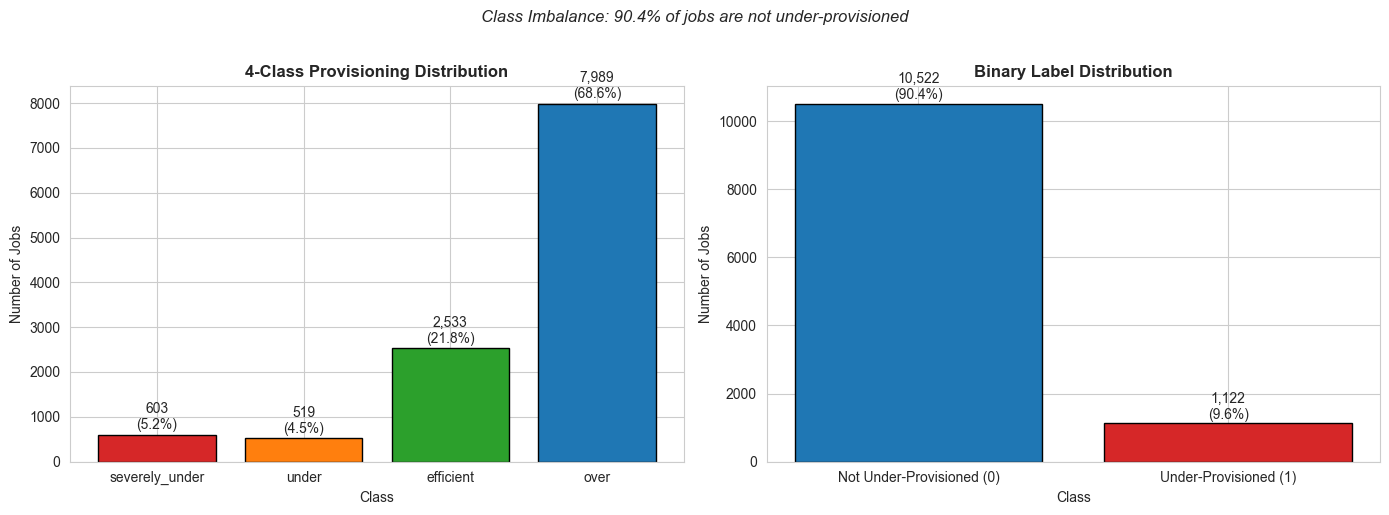


⚠️  Note: Significant class imbalance detected (9.6% vs 90.4%)
   → Will use class_weight='balanced' in all models
   → Primary metric will be RECALL on under-provisioned class, not accuracy


In [4]:
print("=" * 60)
print("SANITY CHECK — 2 EXAMPLES PER CLASS")
print("=" * 60)

for cls in ['severely_under', 'under', 'efficient', 'over']:
    sample = merged_clean[merged_clean['provisioning_class'] == cls][
        ['job_name', 'plan_cpu_cores', 'cpu_max_peak', 'util_ratio_peak', 'provisioning_class']
    ].head(2)
    print(f"\n{cls.upper()}:")
    print(sample.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 4-class distribution
class_order = ['severely_under', 'under', 'efficient', 'over']
counts = [merged_clean['provisioning_class'].eq(c).sum() for c in class_order]
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']

axes[0].bar(class_order, counts, color=colors, edgecolor='black')
axes[0].set_title('4-Class Provisioning Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Jobs')
axes[0].set_xlabel('Class')
for i, (bar, count) in enumerate(zip(axes[0].patches, counts)):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count:,}\n({count/total*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10)

# Binary distribution
axes[1].bar(['Not Under-Provisioned (0)', 'Under-Provisioned (1)'],
            [not_under, under_count],
            color=['#1f77b4', '#d62728'], edgecolor='black')
axes[1].set_title('Binary Label Distribution', fontweight='bold')
axes[1].set_ylabel('Number of Jobs')
axes[1].set_xlabel('Class')
for bar, count in zip(axes[1].patches, [not_under, under_count]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count:,}\n({count/total*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10)

plt.suptitle('Class Imbalance: 90.4% of jobs are not under-provisioned',
             fontsize=12, style='italic', y=1.02)
plt.tight_layout()
plt.show()

print("\n⚠️  Note: Significant class imbalance detected (9.6% vs 90.4%)")
print("   → Will use class_weight='balanced' in all models")
print("   → Primary metric will be RECALL on under-provisioned class, not accuracy")

---
## Section 2: Feature Engineering

We can only use features known **before the job runs** — i.e., from `batch_task` only.
No actual usage columns (`cpu_max_peak`, `cpu_avg_mean`, etc.) can be used as features,
as that would leak the answer into the model.

**Available pre-run features in our dataset:**
- `plan_cpu_cores` — how much CPU the user requested
- `task_count` — number of tasks in the job
- `instance_count` — number of instances spawned

**Derived features we will create:**
- `plan_cpu_per_task` — average CPU requested per task
- `instance_to_task_ratio` — how many instances per task
- `is_multi_task` — binary flag: does the job have more than 1 task?
- `is_large_job` — binary flag: does the job request ≥ 5 cores?
- `cpu_size_bucket_encoded` — integer encoding of the size bucket from Stage 1

In [6]:
print("=" * 60)
print("SECTION 2: FEATURE ENGINEERING")
print("=" * 60)

# Derived features
merged_clean['plan_cpu_per_task'] = (
    merged_clean['plan_cpu_cores'] / merged_clean['task_count']
)

merged_clean['instance_to_task_ratio'] = (
    merged_clean['instance_count'] / merged_clean['task_count']
)

merged_clean['is_multi_task'] = (merged_clean['task_count'] > 1).astype(int)

merged_clean['is_large_job'] = (merged_clean['plan_cpu_cores'] >= 5).astype(int)

# Encode size bucket as integer (ordinal)
bucket_order = {
    'Tiny (0-0.5)' : 0,
    'Small (0.5-1)': 1,
    'Medium (1-2)'  : 2,
    'Large (2-5)'   : 3,
    'XLarge (5-10)' : 4,
    'Huge (10+)'    : 5
}
merged_clean['cpu_size_bucket_encoded'] = (
    merged_clean['size_bucket'].map(bucket_order)
)

# Define final feature list — ONLY pre-run features
FEATURES = [
    'plan_cpu_cores',
    'task_count',
    'instance_count',
    'plan_cpu_per_task',
    'instance_to_task_ratio',
    'is_multi_task',
    'is_large_job',
    'cpu_size_bucket_encoded'
]

print(f"\n Features created: {len(FEATURES)}")
print(f"\nFeature list:")
for f in FEATURES:
    print(f"  {f}: {merged_clean[f].dtype}")

# Null check
print("\n" + "=" * 60)
print("NULL CHECK")
print("=" * 60)
null_counts = merged_clean[FEATURES].isnull().sum()
if null_counts.sum() == 0:
    print("   No nulls found in any feature")
else:
    print(null_counts[null_counts > 0])

# Infinite value check
print("\n" + "=" * 60)
print("INFINITE VALUE CHECK")
print("=" * 60)
inf_counts = np.isinf(merged_clean[FEATURES].select_dtypes(include=np.number)).sum()
if inf_counts.sum() == 0:
    print("   No infinite values found in any feature")
else:
    print(inf_counts[inf_counts > 0])
    merged_clean[FEATURES] = merged_clean[FEATURES].replace(
        [np.inf, -np.inf], np.nan
    ).fillna(0)
    print("  → Replaced inf with NaN, filled with 0")

print(f"\n Feature matrix ready: {merged_clean[FEATURES].shape}")

SECTION 2: FEATURE ENGINEERING

 Features created: 8

Feature list:
  plan_cpu_cores: float64
  task_count: int64
  instance_count: int64
  plan_cpu_per_task: float64
  instance_to_task_ratio: float64
  is_multi_task: int64
  is_large_job: int64
  cpu_size_bucket_encoded: int64

NULL CHECK
   No nulls found in any feature

INFINITE VALUE CHECK
   No infinite values found in any feature

 Feature matrix ready: (11644, 8)


---
### Feature Statistics by Provisioning Class

Before modelling, we examine whether the engineered features differ meaningfully
across provisioning classes. This is the core of the deep dive — understanding
what characterises an under-provisioned job vs an over-provisioned one.

In [7]:
print("=" * 60)
print("FEATURE STATISTICS BY PROVISIONING CLASS")
print("=" * 60)

class_order = ['severely_under', 'under', 'efficient', 'over']

for feature in FEATURES:
    print(f"\n{feature}:")
    print(f"  {'Class':<20} {'Mean':>10} {'Median':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
    print(f"  {'-'*62}")
    for cls in class_order:
        subset = merged_clean[merged_clean['provisioning_class'] == cls][feature]
        print(
            f"  {cls:<20}"
            f" {subset.mean():>10.3f}"
            f" {subset.median():>10.3f}"
            f" {subset.std():>10.3f}"
            f" {subset.min():>10.3f}"
            f" {subset.max():>10.3f}"
        )

FEATURE STATISTICS BY PROVISIONING CLASS

plan_cpu_cores:
  Class                      Mean     Median        Std        Min        Max
  --------------------------------------------------------------
  severely_under            0.717      0.500      0.301      0.400      1.750
  under                     1.089      1.000      0.339      0.400      2.750
  efficient                 1.434      1.000      0.609      0.400      5.500
  over                      4.706      3.500      5.825      0.500    156.000

task_count:
  Class                      Mean     Median        Std        Min        Max
  --------------------------------------------------------------
  severely_under            1.423      1.000      0.549      1.000      3.000
  under                     2.164      2.000      0.742      1.000     12.000
  efficient                 2.511      2.000      1.427      1.000     11.000
  over                      7.344      6.000      7.455      1.000    156.000

instance_count:
  

---
## Section 3: Exploratory Deep Dive — Under-Provisioned vs Over-Provisioned Jobs

We now visualise the feature distributions across provisioning classes.
The goal is to understand what a typical under-provisioned job looks like
compared to an over-provisioned one, and identify which features carry
the most predictive signal.

Split summary:
  Under-provisioned jobs : 1,122
  Not under-provisioned  : 10,522


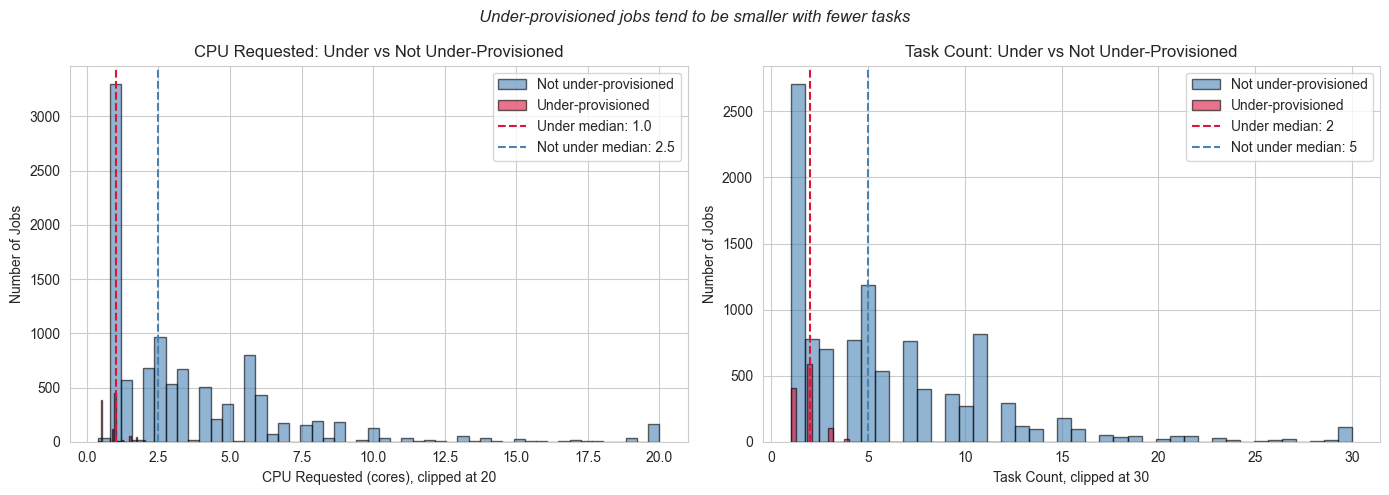

In [8]:
under_df = merged_clean[merged_clean['is_underprovision'] == 1].copy()
not_under_df = merged_clean[merged_clean['is_underprovision'] == 0].copy()

print("Split summary:")
print(f"  Under-provisioned jobs : {len(under_df):,}")
print(f"  Not under-provisioned  : {len(not_under_df):,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# plan_cpu_cores distribution
axes[0].hist(
    not_under_df['plan_cpu_cores'].clip(upper=20),
    bins=50, alpha=0.6, color='steelblue',
    edgecolor='black', label='Not under-provisioned'
)
axes[0].hist(
    under_df['plan_cpu_cores'].clip(upper=20),
    bins=50, alpha=0.6, color='crimson',
    edgecolor='black', label='Under-provisioned'
)
axes[0].set_xlabel('CPU Requested (cores), clipped at 20')
axes[0].set_ylabel('Number of Jobs')
axes[0].set_title('CPU Requested: Under vs Not Under-Provisioned')
axes[0].legend()
axes[0].axvline(
    under_df['plan_cpu_cores'].median(),
    color='crimson', linestyle='--', linewidth=1.5,
    label=f"Under median: {under_df['plan_cpu_cores'].median():.1f}"
)
axes[0].axvline(
    not_under_df['plan_cpu_cores'].median(),
    color='steelblue', linestyle='--', linewidth=1.5,
    label=f"Not under median: {not_under_df['plan_cpu_cores'].median():.1f}"
)
axes[0].legend()

# task_count distribution
axes[1].hist(
    not_under_df['task_count'].clip(upper=30),
    bins=40, alpha=0.6, color='steelblue',
    edgecolor='black', label='Not under-provisioned'
)
axes[1].hist(
    under_df['task_count'].clip(upper=30),
    bins=40, alpha=0.6, color='crimson',
    edgecolor='black', label='Under-provisioned'
)
axes[1].set_xlabel('Task Count, clipped at 30')
axes[1].set_ylabel('Number of Jobs')
axes[1].set_title('Task Count: Under vs Not Under-Provisioned')
axes[1].axvline(
    under_df['task_count'].median(),
    color='crimson', linestyle='--', linewidth=1.5,
    label=f"Under median: {under_df['task_count'].median():.0f}"
)
axes[1].axvline(
    not_under_df['task_count'].median(),
    color='steelblue', linestyle='--', linewidth=1.5,
    label=f"Not under median: {not_under_df['task_count'].median():.0f}"
)
axes[1].legend()

plt.suptitle(
    'Under-provisioned jobs tend to be smaller with fewer tasks',
    fontsize=12, style='italic'
)
plt.tight_layout()
plt.show()

### Instance Count and Instance-to-Task Ratio by Class

Examining whether the number of instances and how they relate to task count
differs across provisioning classes.

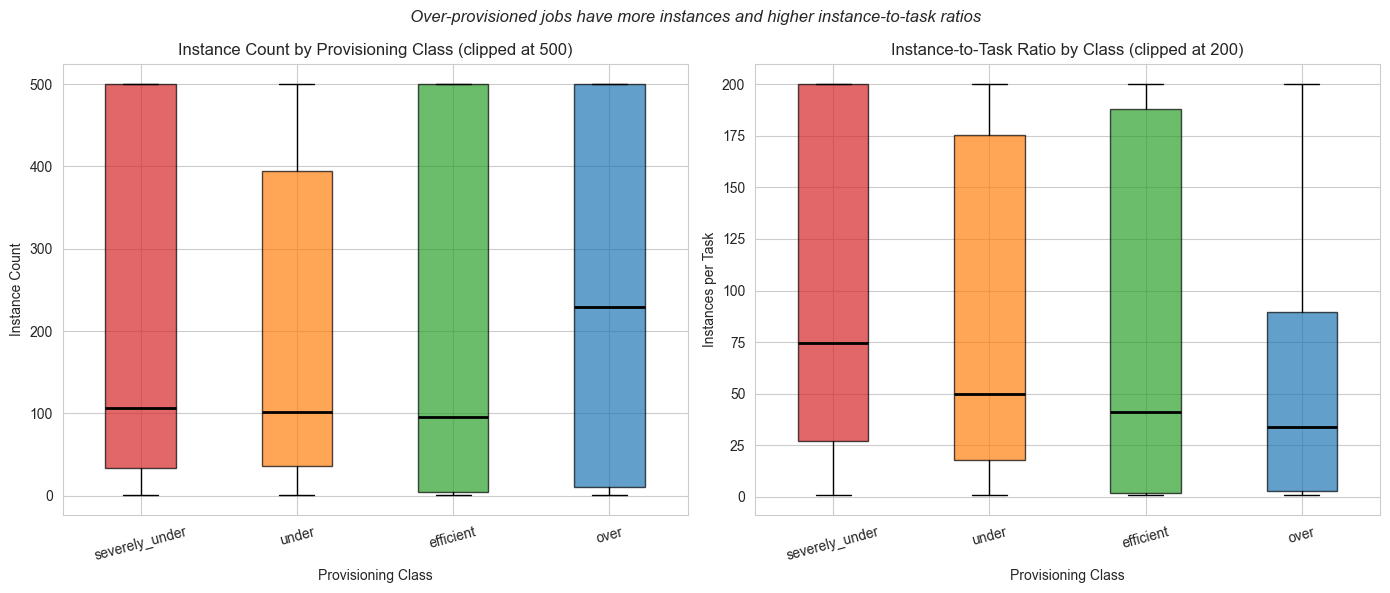

Median instance_count by class:
  severely_under      : 106
  under               : 102
  efficient           : 96
  over                : 229

Median instance_to_task_ratio by class:
  severely_under      : 74.50
  under               : 50.00
  efficient           : 41.00
  over                : 33.67


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

class_order = ['severely_under', 'under', 'efficient', 'over']
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']

# Boxplot: instance_count clipped to remove extreme outliers for visibility
plot_data_instance = [
    merged_clean[merged_clean['provisioning_class'] == cls]['instance_count'].clip(upper=500)
    for cls in class_order
]

bp1 = axes[0].boxplot(
    plot_data_instance,
    labels=class_order,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_title('Instance Count by Provisioning Class (clipped at 500)')
axes[0].set_ylabel('Instance Count')
axes[0].set_xlabel('Provisioning Class')
axes[0].tick_params(axis='x', rotation=15)

# Boxplot: instance_to_task_ratio clipped
plot_data_ratio = [
    merged_clean[merged_clean['provisioning_class'] == cls]['instance_to_task_ratio'].clip(upper=200)
    for cls in class_order
]

bp2 = axes[1].boxplot(
    plot_data_ratio,
    labels=class_order,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title('Instance-to-Task Ratio by Class (clipped at 200)')
axes[1].set_ylabel('Instances per Task')
axes[1].set_xlabel('Provisioning Class')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle(
    'Over-provisioned jobs have more instances and higher instance-to-task ratios',
    fontsize=12, style='italic'
)
plt.tight_layout()
plt.show()

# Print median values for reporting
print("Median instance_count by class:")
for cls in class_order:
    med = merged_clean[merged_clean['provisioning_class'] == cls]['instance_count'].median()
    print(f"  {cls:<20}: {med:.0f}")

print("\nMedian instance_to_task_ratio by class:")
for cls in class_order:
    med = merged_clean[merged_clean['provisioning_class'] == cls]['instance_to_task_ratio'].median()
    print(f"  {cls:<20}: {med:.2f}")

### Scatter Plot and Correlation Analysis

Visualising where under-provisioned jobs sit in the CPU requested vs actual
usage space, and measuring feature correlations with the target variable.

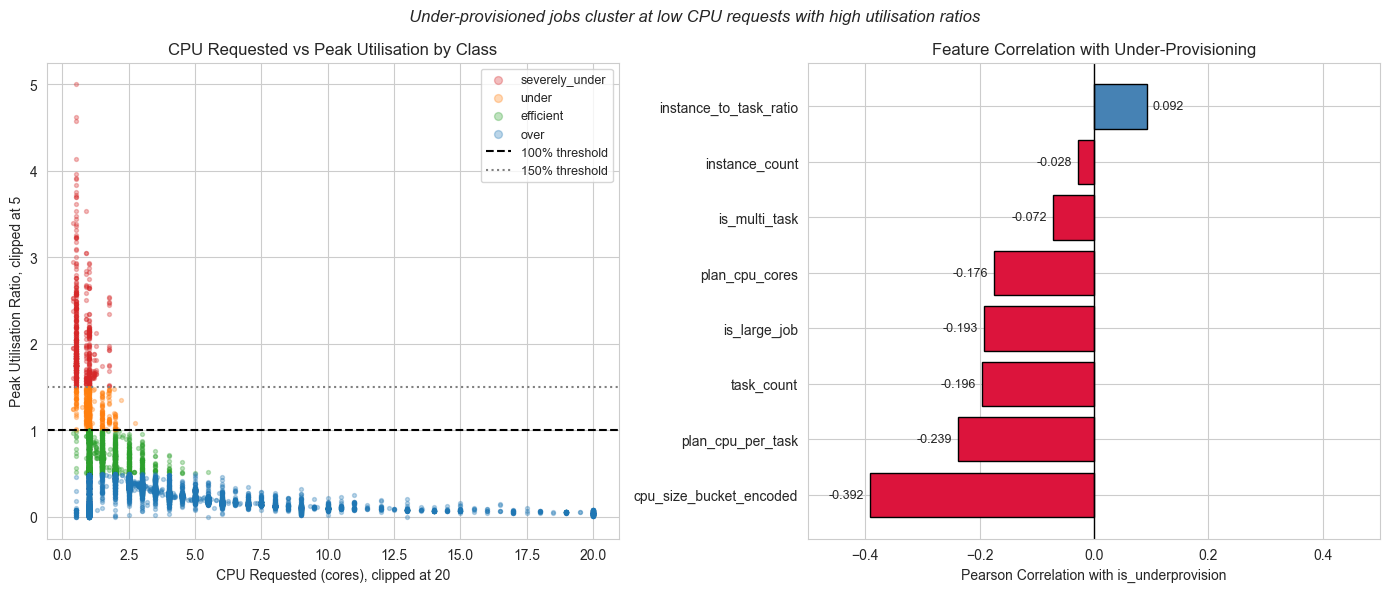

Feature correlations with is_underprovision (sorted):
cpu_size_bucket_encoded   -0.392270
plan_cpu_per_task         -0.238511
task_count                -0.196006
is_large_job              -0.193153
plan_cpu_cores            -0.175523
is_multi_task             -0.071795
instance_count            -0.027718
instance_to_task_ratio     0.092386


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter: plan_cpu_cores vs util_ratio_peak coloured by class
class_colors = {
    'severely_under': '#d62728',
    'under':          '#ff7f0e',
    'efficient':      '#2ca02c',
    'over':           '#1f77b4'
}

for cls, color in class_colors.items():
    subset = merged_clean[merged_clean['provisioning_class'] == cls]
    axes[0].scatter(
        subset['plan_cpu_cores'].clip(upper=20),
        subset['util_ratio_peak'].clip(upper=5),
        alpha=0.3, s=8, color=color, label=cls
    )

axes[0].axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='100% threshold')
axes[0].axhline(1.5, color='grey', linestyle=':', linewidth=1.5, label='150% threshold')
axes[0].set_xlabel('CPU Requested (cores), clipped at 20')
axes[0].set_ylabel('Peak Utilisation Ratio, clipped at 5')
axes[0].set_title('CPU Requested vs Peak Utilisation by Class')
axes[0].legend(markerscale=2, fontsize=9)

# Correlation of features with is_underprovision
correlations = merged_clean[FEATURES + ['is_underprovision']].corr()['is_underprovision'].drop('is_underprovision')
correlations_sorted = correlations.sort_values()

colors_corr = ['crimson' if c < 0 else 'steelblue' for c in correlations_sorted]
axes[1].barh(correlations_sorted.index, correlations_sorted.values,
             color=colors_corr, edgecolor='black')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Pearson Correlation with is_underprovision')
axes[1].set_title('Feature Correlation with Under-Provisioning')
axes[1].set_xlim(-0.5, 0.5)

for i, (val, name) in enumerate(zip(correlations_sorted.values, correlations_sorted.index)):
    axes[1].text(
        val + (0.01 if val >= 0 else -0.01),
        i,
        f'{val:.3f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9
    )

plt.suptitle(
    'Under-provisioned jobs cluster at low CPU requests with high utilisation ratios',
    fontsize=12, style='italic'
)
plt.tight_layout()
plt.show()

print("Feature correlations with is_underprovision (sorted):")
print(correlations_sorted.to_string())

---
### Deep Dive Observations

**What characterises an under-provisioned job:**

1. Small CPU request — median 1.0 core vs 2.5 cores for not under-provisioned jobs.
   Nearly all under-provisioned jobs request 2 cores or fewer. Beyond 2 cores,
   under-provisioning becomes rare.

2. Few tasks — median 2 tasks vs 5 tasks for not under-provisioned jobs.
   Single-task jobs are the highest risk group.

3. Low CPU per task — the strongest correlation after size bucket (-0.24).
   Jobs that request little CPU per individual task tend to underestimate their
   total workload.

4. Instance count and instance-to-task ratio are noisy features with near-zero
   correlation to the target. They will be included in the model but are not
   expected to contribute meaningfully.

**Feature ranking by predictive signal (Pearson correlation with target):**

| Rank | Feature | Correlation |
|------|---------|-------------|
| 1 | cpu_size_bucket_encoded | -0.392 |
| 2 | plan_cpu_per_task | -0.239 |
| 3 | task_count | -0.196 |
| 4 | is_large_job | -0.193 |
| 5 | plan_cpu_cores | -0.176 |
| 6 | is_multi_task | -0.072 |
| 7 | instance_count | -0.028 |
| 8 | instance_to_task_ratio | +0.092 |

**Key finding:** Under-provisioning is essentially a small-job phenomenon.
Large jobs over-provision out of caution; small jobs under-provision because
users underestimate how much CPU a lightweight workload actually consumes.
This has a direct implication for the recommendation engine — correction
should be targeted specifically at jobs requesting 2 cores or fewer.